# `CoordinationGrid` demo — scripted partner over `train_0002` .. `train_0006`

The partner is now scripted and message-conditioned. Each round:
  * Ego (agent_0) picks a joint (move, message) action per step (15 total).
  * At `t=0`, both agents stay; only ego's message is transmitted.
  * At `t=1`, the partner commits to RED or BLUE based on the t=0 message and partner-type `z`:
     `P(RED | M0, z) = z`, `P(RED | M1, z) = 1 - z`, `P(RED | NONE) = 0.5`.
  * From `t=1` onward the partner navigates greedily along a precomputed BFS table toward its committed goal.
  * Ego observation is a dict `{"grid": (H,W,5), "last_message": (3,)}` — the last_message lets an RNN correlate its own utterances with partner responses.

This notebook runs each grid twice — once with `z=1` (M0→RED, so ego heads to BLUE) and once with `z=0` (M0→BLUE, so ego heads to RED) — and verifies both variants coordinate.

In [1]:
import os, json
from collections import deque

import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, Circle

import jaxmarl
from jaxmarl.environments.coordination_grid import (
    CoordinationGrid, State, Actions, Messages,
    encode_ego, decode_ego,
    N_MOVES, N_MESSAGES, N_EGO_ACTIONS,
    GOAL_UNSET, GOAL_RED, GOAL_BLUE,
)

UP, DOWN, RIGHT, LEFT, STAY = 0, 1, 2, 3, 4
NONE, M0, M1 = 0, 1, 2
MOVE_NAME = {0:'U', 1:'D', 2:'R', 3:'L', 4:'.'}
MSG_NAME  = {0:'-', 1:'m0', 2:'m1'}

REPO_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
LAYOUTS_DIR = os.path.join(REPO_ROOT, 'dev', 'grids', 'layouts', 'train')
LAYOUT_IDS = [f'train_{i:04d}' for i in range(2, 7)]
print('layouts:', LAYOUT_IDS)

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


2026-09-24 00:40:27.775634: E external/xla/xla/stream_executor/cuda/cuda_driver.cc:273] failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected
CUDA backend failed to initialize: FAILED_PRECONDITION: No visible GPU devices. (Set TF_CPP_MIN_LOG_LEVEL=0 and rerun for more info.)


layouts: ['train_0002', 'train_0003', 'train_0004', 'train_0005', 'train_0006']


## Load envs and render initial states
One env per layout; give plenty of navigation budget (`max_steps=25`).

In [2]:
def make_env(layout_id, partner_z=1.0, max_steps=25):
    path = os.path.join(LAYOUTS_DIR, f'{layout_id}.json')
    return CoordinationGrid(layout_path=path, max_steps=max_steps, partner_z=partner_z)

envs_z1 = {lid: make_env(lid, partner_z=1.0) for lid in LAYOUT_IDS}
envs_z0 = {lid: make_env(lid, partner_z=0.0) for lid in LAYOUT_IDS}

for lid, env in envs_z1.items():
    print(f'{lid}: H={env.height} W={env.width}  ego={tuple(np.array(env.ego_start))}  '
          f'partner={tuple(np.array(env.partner_start))}  '
          f'red={tuple(np.array(env.red_goal))}  blue={tuple(np.array(env.blue_goal))}')

train_0002: H=7 W=7  ego=(4, 2)  partner=(5, 4)  red=(6, 4)  blue=(3, 6)
train_0003: H=7 W=7  ego=(4, 5)  partner=(2, 6)  red=(2, 2)  blue=(6, 1)
train_0004: H=7 W=7  ego=(2, 6)  partner=(6, 2)  red=(4, 5)  blue=(0, 5)
train_0005: H=7 W=7  ego=(0, 1)  partner=(1, 4)  red=(5, 4)  blue=(0, 4)
train_0006: H=7 W=7  ego=(3, 4)  partner=(1, 3)  red=(2, 1)  blue=(6, 6)


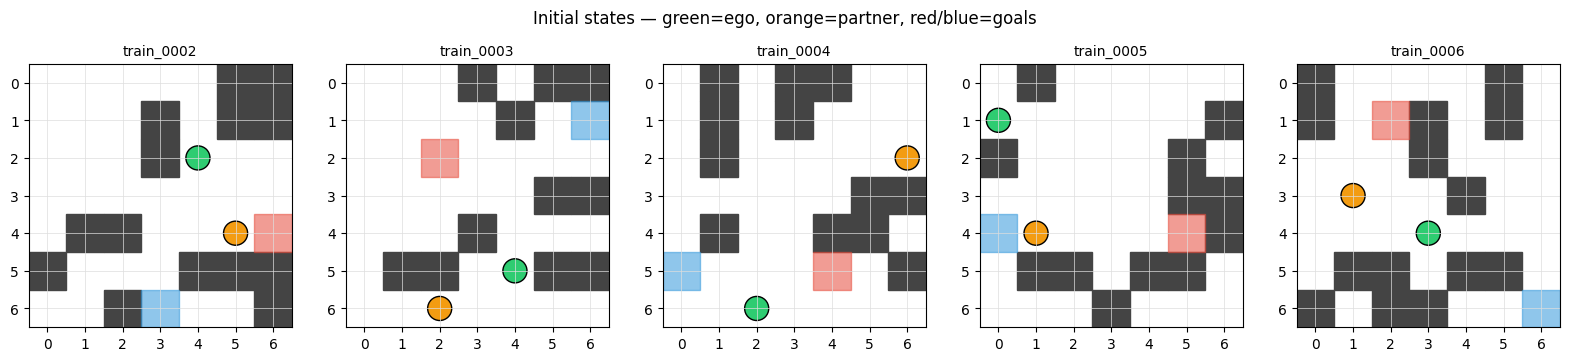

In [3]:
def render(ax, env, state, title=''):
    H, W = env.height, env.width
    wall = np.array(state.wall_map)
    ax.set_xlim(-0.5, W - 0.5); ax.set_ylim(H - 0.5, -0.5)
    ax.set_xticks(range(W)); ax.set_yticks(range(H))
    ax.set_aspect('equal'); ax.grid(True, color='#dddddd', linewidth=0.5)
    for y in range(H):
        for x in range(W):
            if wall[y, x]:
                ax.add_patch(Rectangle((x-0.5, y-0.5), 1, 1, color='#444444'))
    rx, ry = int(state.red_goal[0]), int(state.red_goal[1])
    bx, by = int(state.blue_goal[0]), int(state.blue_goal[1])
    ax.add_patch(Rectangle((rx-0.5, ry-0.5), 1, 1, color='#e74c3c', alpha=0.55))
    ax.add_patch(Rectangle((bx-0.5, by-0.5), 1, 1, color='#3498db', alpha=0.55))
    ex, ey = int(state.agent_pos[0, 0]), int(state.agent_pos[0, 1])
    px, py = int(state.agent_pos[1, 0]), int(state.agent_pos[1, 1])
    ax.add_patch(Circle((ex, ey), 0.32, color='#2ecc71', ec='black', lw=1.0))
    ax.add_patch(Circle((px, py), 0.32, color='#f39c12', ec='black', lw=1.0))
    ax.set_title(title, fontsize=10)

key = jax.random.PRNGKey(0)
fig, axes = plt.subplots(1, len(LAYOUT_IDS), figsize=(3.2 * len(LAYOUT_IDS), 3.3))
for ax, lid in zip(axes, LAYOUT_IDS):
    env = envs_z1[lid]
    _, s0 = env.reset(key)
    render(ax, env, s0, title=lid)
fig.suptitle('Initial states — green=ego, orange=partner, red/blue=goals', y=1.02)
plt.tight_layout(); plt.show()

## Signal-and-solve strategy
For each grid + `z`, work out which message routes the partner to which goal, then compute the ego's BFS path to the *other* goal. Ego action sequence:
  * `t=0`: `encode_ego(STAY, message)` — free comm.
  * `t≥1`: `encode_ego(bfs_move, NONE)`.

In [4]:
def bfs_actions(wall, sx, sy, gx, gy):
    H, W = wall.shape
    if (sx, sy) == (gx, gy):
        return []
    visited = {(sx, sy): None}
    q = deque([(sx, sy)])
    while q:
        cx, cy = q.popleft()
        if (cx, cy) == (gx, gy):
            break
        for a, dx, dy in [(UP, 0, -1), (DOWN, 0, 1), (RIGHT, 1, 0), (LEFT, -1, 0)]:
            nx, ny = cx + dx, cy + dy
            if 0 <= nx < W and 0 <= ny < H and not wall[ny, nx] and (nx, ny) not in visited:
                visited[(nx, ny)] = ((cx, cy), a)
                q.append((nx, ny))
    if (gx, gy) not in visited:
        return None
    out, cur = [], (gx, gy)
    while visited[cur] is not None:
        prev, a = visited[cur]
        out.append(a); cur = prev
    return list(reversed(out))

def choose_plan(env, z, message):
    """Pick ego's target goal given (z, message) so ego covers the *other* goal.
    Returns (ego_target_name, ego_action_plan)."""
    # Deterministic-partner mapping when z ∈ {0, 1}:
    #   z=1: M0->RED, M1->BLUE, NONE->random -> ego handles NONE branch too
    #   z=0: M0->BLUE, M1->RED, NONE->random
    if z == 1.0:
        partner_goal = 'RED' if message == M0 else ('BLUE' if message == M1 else '?')
    elif z == 0.0:
        partner_goal = 'BLUE' if message == M0 else ('RED' if message == M1 else '?')
    else:
        partner_goal = '?'
    ego_goal_name = 'BLUE' if partner_goal == 'RED' else 'RED'
    ego_goal_xy = np.array(env.blue_goal) if ego_goal_name == 'BLUE' else np.array(env.red_goal)
    wall = np.array(env.wall_map)
    ex, ey = int(env.ego_start[0]), int(env.ego_start[1])
    plan = bfs_actions(wall, ex, ey, int(ego_goal_xy[0]), int(ego_goal_xy[1]))
    return ego_goal_name, partner_goal, plan

## Run each grid twice: `z=1` and `z=0` (both with `M0` at `t=0`)
With `z=1` the partner heads to RED, so ego goes to BLUE. With `z=0` the same `M0` routes the partner to BLUE, so ego goes to RED. Verifies that identical ego strategy + identical message produces opposite partner behavior under different `z`.

In [5]:
def rollout(env, message, ego_plan, key):
    _, state = env.reset(key)
    states = [state]
    rewards, dones, infos = [], [], []

    # t=0 free-comm step
    _, state, r, d, info = env.step_env(key, state, {'agent_0': encode_ego(STAY, message)})
    states.append(state); rewards.append(float(r['agent_0'])); dones.append(bool(d['__all__'])); infos.append(info)

    for i in range(env.max_steps - 1):
        mv = ego_plan[i] if i < len(ego_plan) else STAY
        _, state, r, d, info = env.step_env(key, state, {'agent_0': encode_ego(mv, NONE)})
        states.append(state); rewards.append(float(r['agent_0'])); dones.append(bool(d['__all__'])); infos.append(info)
        if dones[-1]:
            break
    return states, rewards, dones, infos

def run_one(lid, z, message):
    env = envs_z1[lid] if z == 1.0 else envs_z0[lid]
    ego_goal, partner_goal, plan = choose_plan(env, z, message)
    states, rewards, dones, infos = rollout(env, message, plan, key)
    committed = int(states[-1].partner_goal)
    committed_name = {GOAL_UNSET:'UNSET', GOAL_RED:'RED', GOAL_BLUE:'BLUE'}[committed]
    return dict(env=env, z=z, message=message, ego_goal=ego_goal,
                partner_goal_expected=partner_goal, partner_goal_committed=committed_name,
                plan=plan, states=states, rewards=rewards, dones=dones, infos=infos)

results = {}
for lid in LAYOUT_IDS:
    results[(lid, 1.0)] = run_one(lid, 1.0, M0)
    results[(lid, 0.0)] = run_one(lid, 0.0, M0)

print(f'{"layout":<12} {"z":>4}  {"msg":>4}  {"partner":>7}  {"ego":>4}  {"steps":>5}  {"total":>7}  {"final r":>8}  {"success":>7}')
for (lid, z), r in results.items():
    tot = sum(r['rewards'])
    print(f'{lid:<12} {z:>4.1f}  {MSG_NAME[r["message"]]:>4}  '
          f'{r["partner_goal_committed"]:>7}  {r["ego_goal"]:>4}  '
          f'{len(r["rewards"]):>5d}  {tot:+7.3f}  '
          f'{r["rewards"][-1]:+8.3f}  {str(bool(r["infos"][-1]["success"])):>7}')

layout          z   msg  partner   ego  steps    total   final r  success
train_0002    1.0    m0      RED  BLUE      6   +0.950    +1.000     True
train_0002    0.0    m0     BLUE   RED      5   +0.960    +1.000     True
train_0003    1.0    m0      RED  BLUE      9   +0.920    +1.000     True
train_0003    0.0    m0     BLUE   RED     10   +0.910    +1.000     True
train_0004    1.0    m0      RED  BLUE      8   +0.930    +1.000     True
train_0004    0.0    m0     BLUE   RED     10   +0.910    +1.000     True
train_0005    1.0    m0      RED  BLUE      6   +0.950    +1.000     True
train_0005    0.0    m0     BLUE   RED      9   +0.920    +1.000     True
train_0006    1.0    m0      RED  BLUE      6   +0.950    +1.000     True
train_0006    0.0    m0     BLUE   RED      9   +0.920    +1.000     True


## Initial vs. final state for each (grid, z)
Two rows per grid: `z=1` on top, `z=0` on bottom. Green disk = ego, orange disk = partner. The partner's committed goal (RED vs. BLUE) flips as `z` flips, since the same `M0` message now means the opposite thing.

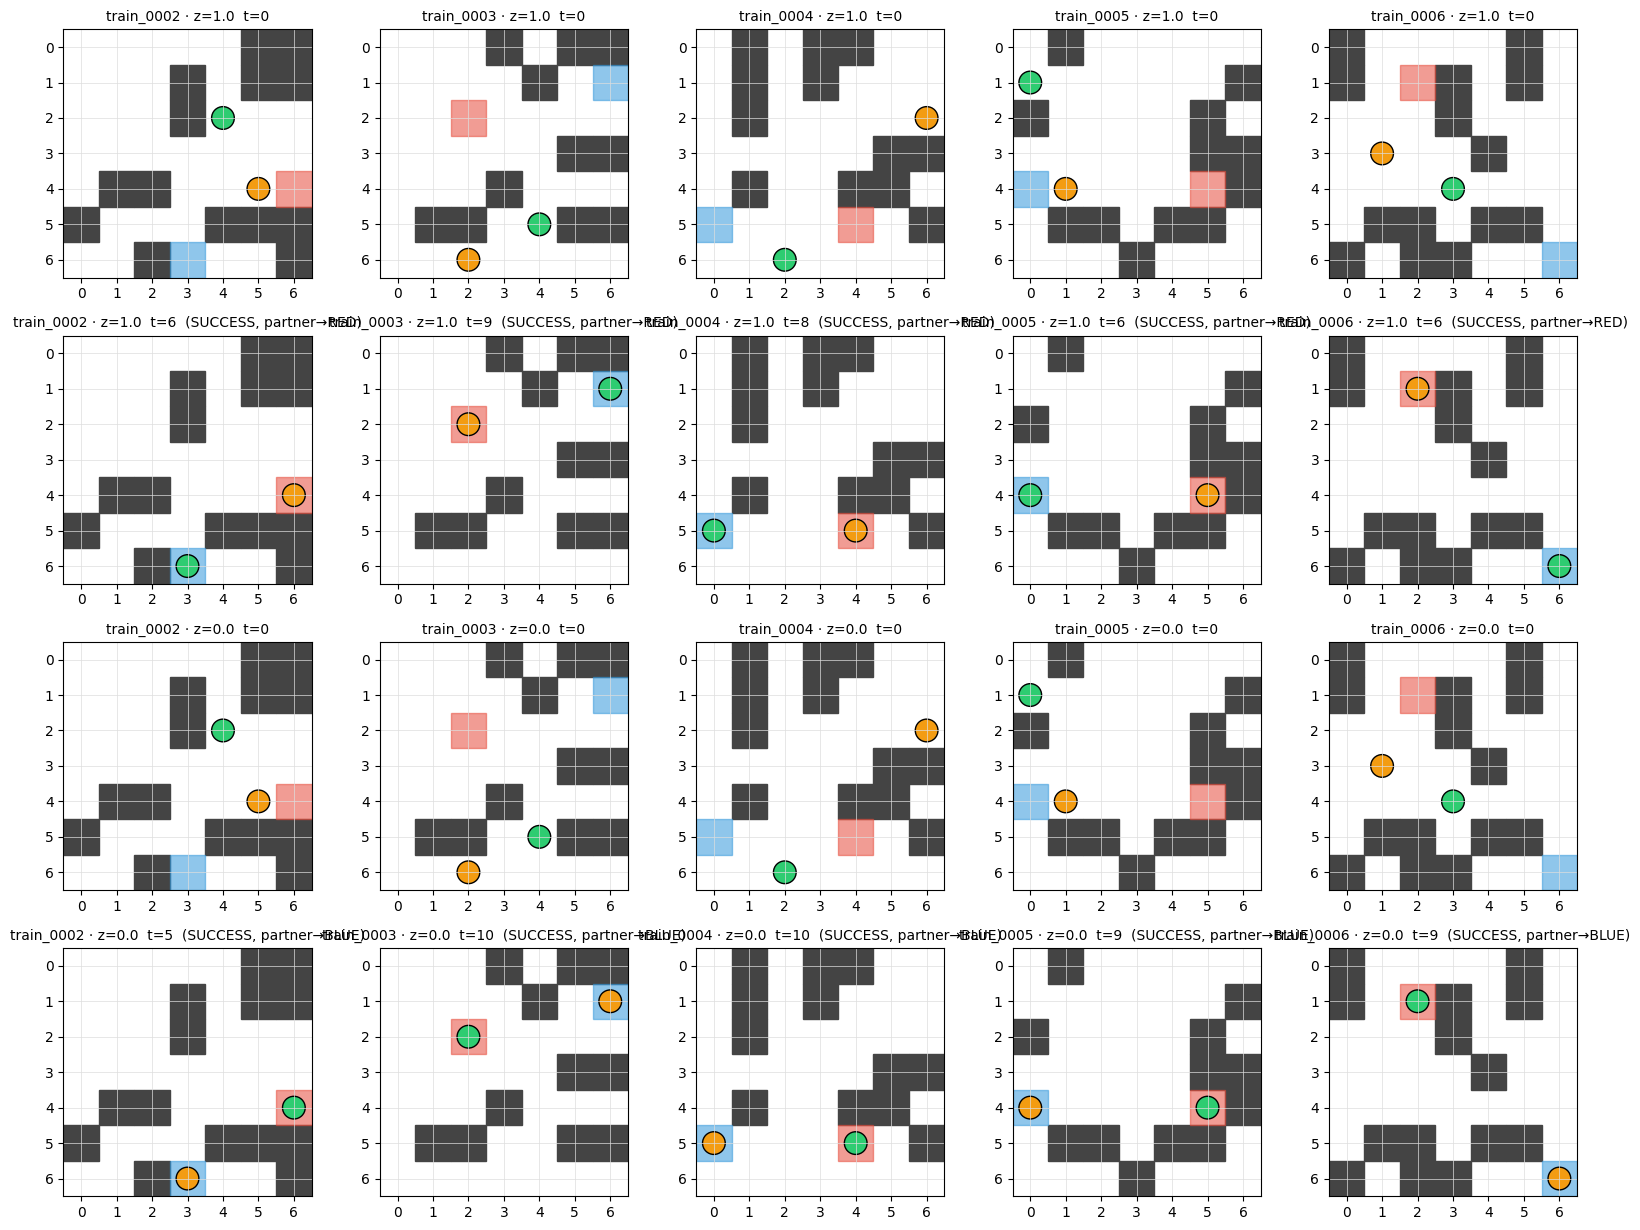

In [6]:
cols = len(LAYOUT_IDS)
fig, axes = plt.subplots(4, cols, figsize=(3.2 * cols, 12.4))
for col, lid in enumerate(LAYOUT_IDS):
    for r_i, z in enumerate([1.0, 0.0]):
        r = results[(lid, z)]
        env = r['env']
        s0 = r['states'][0]; sT = r['states'][-1]
        succ = bool(r['infos'][-1]['success'])
        tag = 'SUCCESS' if succ else 'timeout'
        render(axes[2*r_i,   col], env, s0, title=f'{lid} · z={z}  t=0')
        render(axes[2*r_i+1, col], env, sT,
               title=f'{lid} · z={z}  t={len(r["states"])-1}  ({tag}, partner→{r["partner_goal_committed"]})')
plt.tight_layout(); plt.show()

## Ego observation dict
Every step the ego sees `{grid: (H,W,5), last_message: (3,)}`. `last_message` is a one-hot over `{NONE, M0, M1}` reflecting the message ego sent on the previous step — that's the signal the ego needs to correlate its own utterance with the partner's committed goal (visible via geometry over time).

In [7]:
GOAL_NAME = {0: '-', 1: 'RED', 2: 'BLUE'}
focus = results[(LAYOUT_IDS[0], 1.0)]
env = focus['env']
print(f"trace for {LAYOUT_IDS[0]} at z=1:")
for t, s in enumerate(focus['states']):
    obs = env.get_obs(s)['agent_0']
    ep = tuple(int(v) for v in s.agent_pos[0])
    pp = tuple(int(v) for v in s.agent_pos[1])
    lm = np.array(obs['last_message']).tolist()
    pm = MSG_NAME[int(s.pending_message)]
    pg = GOAL_NAME[int(s.partner_goal)]
    print(f"  t={t}  ego@{ep}  partner@{pp}  pending_message={pm}  obs.last_message={lm}  partner_goal={pg}")

trace for train_0002 at z=1:
  t=0  ego@(4, 2)  partner@(5, 4)  pending_message=-  obs.last_message=[1.0, 0.0, 0.0]  partner_goal=-
  t=1  ego@(4, 2)  partner@(5, 4)  pending_message=m0  obs.last_message=[0.0, 1.0, 0.0]  partner_goal=-
  t=2  ego@(4, 3)  partner@(6, 4)  pending_message=-  obs.last_message=[1.0, 0.0, 0.0]  partner_goal=RED
  t=3  ego@(4, 4)  partner@(6, 4)  pending_message=-  obs.last_message=[1.0, 0.0, 0.0]  partner_goal=RED
  t=4  ego@(3, 4)  partner@(6, 4)  pending_message=-  obs.last_message=[1.0, 0.0, 0.0]  partner_goal=RED
  t=5  ego@(3, 5)  partner@(6, 4)  pending_message=-  obs.last_message=[1.0, 0.0, 0.0]  partner_goal=RED
  t=6  ego@(3, 6)  partner@(6, 4)  pending_message=-  obs.last_message=[1.0, 0.0, 0.0]  partner_goal=RED


## Reward curves

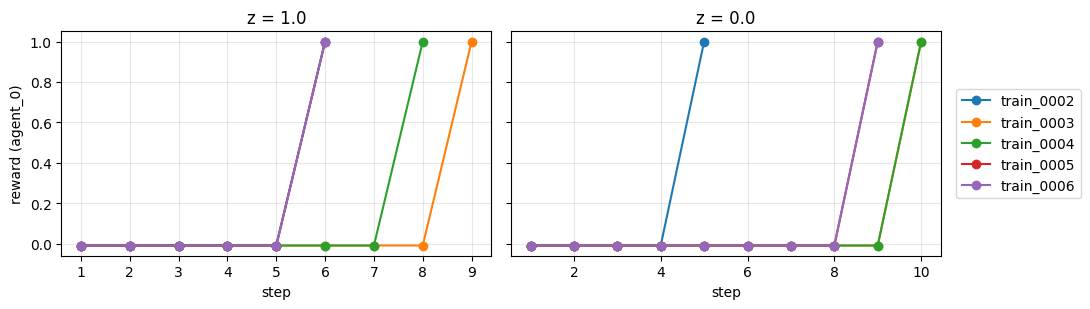

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.2), sharey=True)
for ax, z in zip(axes, [1.0, 0.0]):
    for lid in LAYOUT_IDS:
        rs = results[(lid, z)]['rewards']
        ax.plot(range(1, len(rs) + 1), rs, marker='o', label=lid)
    ax.set_title(f'z = {z}'); ax.set_xlabel('step'); ax.grid(True, alpha=0.3)
axes[0].set_ylabel('reward (agent_0)')
axes[-1].legend(loc='center left', bbox_to_anchor=(1.02, 0.5))
plt.tight_layout(); plt.show()

## JIT + `vmap` smoke test across the 5 grids

In [9]:
any_env = envs_z1[LAYOUT_IDS[0]]
reset_states = []
for lid in LAYOUT_IDS:
    _, s = envs_z1[lid].reset(key)
    reset_states.append(s)
batched_state = jax.tree_util.tree_map(lambda *xs: jnp.stack(xs, axis=0), *reset_states)
print('batched agent_pos', batched_state.agent_pos.shape,
      'wall_map', batched_state.wall_map.shape,
      'partner_goal', batched_state.partner_goal.shape,
      'pending_message', batched_state.pending_message.shape,
      'z', batched_state.z.shape)

actions_batch = {
    'agent_0': jnp.array(
        [encode_ego(STAY, M0)] * len(LAYOUT_IDS),
        dtype=jnp.int32,
    )
}
step_v = jax.jit(jax.vmap(any_env.step_env, in_axes=(None, 0, {'agent_0': 0})))
obs_b, state_b, r_b, d_b, info_b = step_v(key, batched_state, actions_batch)
print('after 1 step:')
print('  grid obs shape:', obs_b['agent_0']['grid'].shape)
print('  last_message  :', np.array(obs_b['agent_0']['last_message']))
print('  reward        :', np.array(r_b['agent_0']))
print('  done          :', np.array(d_b['__all__']))
print('  time          :', np.array(state_b.time))
print('  pending_message after t=0:', np.array(state_b.pending_message))

batched agent_pos (5, 2, 2) wall_map (5, 7, 7) partner_goal (5,) pending_message (5,) z (5,)


after 1 step:
  grid obs shape: (5, 7, 7, 5)
  last_message  : [[0. 1. 0.]
 [0. 1. 0.]
 [0. 1. 0.]
 [0. 1. 0.]
 [0. 1. 0.]]
  reward        : [-0.01 -0.01 -0.01 -0.01 -0.01]
  done          : [False False False False False]
  time          : [1 1 1 1 1]
  pending_message after t=0: [1 1 1 1 1]


## Summary
For each of `train_0002` .. `train_0006`, running the same ego strategy (send `M0` at `t=0`, then follow a BFS plan to the goal opposite to the partner's) succeeds under both `z=1` and `z=0`: the same message routes the partner to opposite goals, and the ego dynamically targets the complementary one. The obs dict `{grid, last_message}` gives an RNN both the geometric state and its own prior utterance — the pair needed to infer `z` from partner reactions.